<a href="https://githubtocolab.com/tannialhernandez/topicosAvanzadosAnalitica/blob/main/P1-FrailejonDetection/P0_BigMonksDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Frailejon Detection (a.k.a "Big Monks Detection")


En este cuadernos continuaremos con nuestra aproximación a las redes neuronales de la mano con la clasificación de imagenes.

Usted debe construir una red neuronal para detectar automáticamente plantas nativas (frailejones) sobre imagenes aerea páramo de Chingaza y Cruz Verde.

**Business Problem Framming**: Este caso de estudio hace parte de un proyecto de Ingeniería que busca preservar y monitorizar el ecosistema del páramo, de gran importancia por su potencial hídrico, mediante la propuesta de una metodología para la reconstrucción del ecosistema en zonas de baja densidad de poblaciones de la especia _Espeletia_.

## Data
Input:

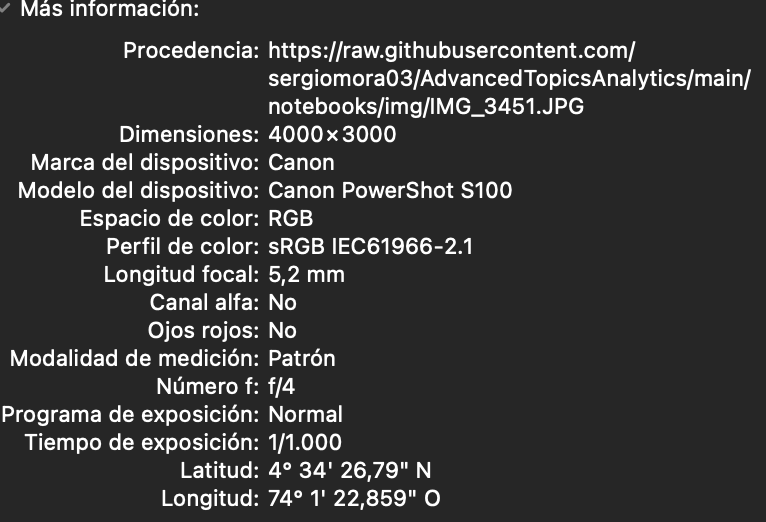

Output:
1. probability that it is a Big Monk.
2. Calculate Big Monks density

## Evaluation

- 30% Report with all the details of the solution, the analysis and the conclusions. The report cannot exceed 10 pages, must be send in PDF format and must be self-contained.
- 30% Code with the data processing and models developed that support the reported results.
- 30% Presentation of no more than 15 minutes with the main results of the project.
- 10% Model performance achieved. Metric: "AUC".


## Requirements

- The project must be carried out in groups of 4 people.
- Use clear and rigorous procedures.
- The delivery of the project is on September 6th, 2024, 11:59 pm, through email with Github link.
- No projects will be received after the delivery time or by any other means than the one established.

## Suggestions

* Use an hyperparameter optimization framework, you can also make grid optimziation or bayesian optimization. Bonus with use:  [Optuna - A hyperparameter optimization framework](https://optuna.org/)
* Remember cualitative analysis with validation image: `IMG_3451.JPG`
* Estimate density for each Big Monks population detected. Bonus with: [Gaussian Mixture Models](https://nbviewer.jupyter.org/github/sergiomora03/Gaussian_Mixture_Models/blob/master/intro_to_gmm_%26_em.ipynb)

## Acknowledgements
We thank Professor Camilo Franco, Ph.D.

In [14]:
import urllib
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

try:
    import numpy as np
except ImportError as e:
    error = str(e)
    lib = error.split()[-1].replace("'", "")
    print(f"\033[32mIntalling {lib}\033[0m")
    !pip install numpy==2.1.3
    import numpy as np

try:
    import matplotlib.pyplot as plt
except ImportError as e:
    error = str(e)
    lib = error.split()[-1].replace("'", "")
    print(f"\033[32mIntalling {lib}\033[0m")
    !pip install matplotlib==3.10.0
    import matplotlib.pyplot as plt

try:
    import sklearn
    import sklearn.datasets
    import sklearn.linear_model
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
except ImportError as e:
    error = str(e)
    lib = error.split()[-1].replace("'", "")
    print(f"\033[32mIntalling {lib}\033[0m")
    !pip install scikit-learn==1.6.1
    import sklearn
    import sklearn.datasets
    import sklearn.linear_model
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

try:
    import h5py
except ImportError as e:
    error = str(e)
    lib = error.split()[-1].replace("'", "")
    print(f"\033[32mIntalling {lib}\033[0m")
    !pip install h5py==3.13.0
    import h5py

try:
    import optuna
    from optuna.trial import TrialState
except ImportError as e:
    error = str(e)
    lib = error.split()[-1].replace("'", "")
    print(f"\033[32mIntalling {lib}\033[0m")
    !pip install optuna==4.2.1
    import optuna
    from optuna.trial import TrialState

try:
    from optuna.integration import KerasPruningCallback
except ImportError as e:
    error = str(e)
    lib = error.split()[-1].replace("'", "")
    print(f"\033[32mIntalling {lib}\033[0m")
    !pip install optuna-integration[keras]==4.2.1
    from optuna.integration import KerasPruningCallback

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
except ImportError as e:
    error = str(e)
    lib = error.split()[-1].replace("'", "")
    print(f"\033[32mIntalling {lib}\033[0m")
    !pip install tensorflow==2.19.0
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    
try:
    import keras
    from keras.utils import to_categorical
    from keras.layers import Dense
    from keras.layers import Dropout
    from keras.models import Sequential
    from keras.optimizers import RMSprop
    from tensorflow.keras.utils import load_img
except ImportError as e:
    error = str(e)
    lib = error.split()[-1].replace("'", "")
    print(f"\033[32mIntalling {lib}\033[0m")
    !pip install keras==3.9.0
    import keras
    from keras.utils import to_categorical
    from keras.layers import Dense
    from keras.layers import Dropout
    from keras.models import Sequential
    from keras.optimizers import RMSprop
    from tensorflow.keras.utils import load_img
    
try:
    import cv2
except ImportError as e:
    error = str(e)
    lib = error.split()[-1].replace("'", "")
    print(f"\033[32mIntalling {lib}\033[0m")
    !pip install opencv-python==4.11.0.86

%matplotlib inline

## Conjunto de datos

Para el entrenamiento de la red neuronal, se usará el archivo `data_F`. Debe divirse en dos grupos, conjunto de entrenamiento (CE) y conjunto de validación (CV).

Adicionalmente, fuera de las métricas del modelo, se requiere que extraiga un análisis cualitativo con la imagen `IMG_3451.JPG`, donde muestre los Frilejones detectados en el area del páramo tomado por la fotografía.

Recuerde, primero, cargamos el conjunto de datos sobre el que se va a trabajar. El siguiente código va a cargar un conjunto de datos `X` e `Y` donde `Y`es una variable binaria.

In [ ]:
urllib.request.urlretrieve(
    'https://raw.githubusercontent.com/tannialhernandez/topicosAvanzadosAnalitica/refs/heads/main/P1-FrailejonDetection/ImportImagenes_mod.py',
    'ImportImagenes_mod.py'
  )

urllib.request.urlretrieve('https://github.com/sergiomora03/AdvancedTopicsAnalytics/blob/main/notebooks/img/IMG_3451.JPG?raw=true', 'IMG_3451.JPG')

In [6]:
from ImportImagenes_mod import *
CE_x, CV_x, CE_y, CV_y = import_imagenes()
CE_x, CV_x, CE_y, CV_y = CE_x.T, CV_x.T, CE_y.T, CV_y.T

CE_x = CE_x.astype("float32")
CV_x = CV_x.astype("float32")

print("\nEntrenamiento:")
print("CE_x shape:\n", CE_x.shape)
print("CE_y shape:\n", CE_y.shape)

print("\nValidación:")
print("CV_x shape:\n", CV_x.shape)
print("CV_y shape:\n", CV_y.shape)

Dimensión de X_train: (14700, 2600)
Dimensión de X_test: (14700, 50)
Dimensión de y_train: (1, 2600)
Dimensión de y_test: (1, 50)

Entrenamiento:
CE_x shape:
 (2600, 14700)
CE_y shape:
 (2600, 1)

Validación:
CV_x shape:
 (50, 14700)
CV_y shape:
 (50, 1)


## Caso Aplicado

### Cálculo de cantidad de Frilejones

vamos a aplicar al menos 5 modelos, se estiman los siguientes valores como resultado del entrenamiento:



*   Sencilla --> 0.88
*   Multi-capa --> 0.95
*  Convolucional --> 0.95
*  Convolucional + VGG16 --> 0.99



1. Implementa una red neuronal sencilla.

In [7]:
BATCHSIZE = 100
EPOCHS = 50

def create_model(trial):
    # We optimize the number of layers, hidden units and dropout in each layer and
    # the learning rate of RMSProp optimizer.

    # We define our MLP.
    n_layers =  2 # trial.suggest_int("n_layers", 2, 4)
    activation_functs = ["relu", "tanh", "sigmoid", "leaky_relu"]
    model = Sequential()
    for i in range(n_layers):
        # activation = trial.suggest_categorical("activation_l{}".format(i), activation_functs)
        if i == 0:
            num_hidden = trial.suggest_int("n_units_l{}".format(i), 71, 111, log=True)
            model.add(Dense(num_hidden, activation="leaky_relu"))
            dropout = trial.suggest_float("dropout_l{}".format(i), 0.2, 0.4)
            model.add(Dropout(rate=dropout))
        if i == 1:
            num_hidden = trial.suggest_int("n_units_l{}".format(i), 45, 85, log=True)
            model.add(Dense(num_hidden, activation="leaky_relu"))
            dropout = trial.suggest_float("dropout_l{}".format(i), 0.2, 0.35)
            model.add(Dropout(rate=dropout))
    model.add(Dense(1, activation="sigmoid"))

    # We compile our model with a sampled learning rate.
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-4, log=True)
    model.compile(
        loss="binary_crossentropy",
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=["accuracy"],
    )

    return model

def objective(trial):
    global CE_x, CV_x, CE_y, CV_y

    # Clear previous session graphs
    keras.backend.clear_session()

    # Load train and validation data
    (x_train, y_train), (x_valid, y_valid) = (CE_x, CE_y), (CV_x, CV_y)


    # Create model
    model = create_model(trial)

    # Define callbacks
    early_stopping_callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=5)

    # Train model
    history = model.fit(
        x_train,
        y_train,
        batch_size=BATCHSIZE,
        callbacks=[KerasPruningCallback(trial, "val_accuracy"), early_stopping_callback],
        epochs=EPOCHS,
        validation_data=(x_valid, y_valid),
        verbose=0
    )

    # Get last recorded accuracies
    last_train_accuracy = history.history["accuracy"][-1]
    last_val_accuracy = history.history["val_accuracy"][-1]

    # Weighted sum to balance both metrics (adjust weights as needed)
    return 0.80 * last_train_accuracy + 0.2 * last_val_accuracy  # Equal weight for both

def main(n_trials):
    prune = optuna.pruners.MedianPruner(
            n_startup_trials=10,  
            n_warmup_steps=10,    
            interval_steps=1     
        )
    study = optuna.create_study(direction="maximize", pruner=prune)
    study.optimize(objective, n_trials=n_trials)
    pruned_trials = study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
    complete_trials = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])
    print("Study statistics: ")
    print("  Number of finished trials: ", len(study.trials))
    print("  Number of pruned trials: ", len(pruned_trials))
    print("  Number of complete trials: ", len(complete_trials))

    print("\nBest trial:")
    trial = study.best_trial

    print("  Value: ", trial.value)

    print("  Params: ")
    for key, value in trial.params.items():
        print("    {}: {}".format(key, value))
    return trial

In [8]:
best_trial = main(100)

[I 2025-03-21 13:29:52,884] A new study created in memory with name: no-name-5e95a810-2aac-4c94-847d-af21ae1a71f3
[I 2025-03-21 13:30:06,098] Trial 0 finished with value: 0.8772307753562928 and parameters: {'n_units_l0': 80, 'dropout_l0': 0.36700170403333976, 'n_units_l1': 47, 'dropout_l1': 0.30993053945898874, 'learning_rate': 1.971698534262288e-05}. Best is trial 0 with value: 0.8772307753562928.
[I 2025-03-21 13:30:17,705] Trial 1 finished with value: 0.8738461375236511 and parameters: {'n_units_l0': 105, 'dropout_l0': 0.2941421278257244, 'n_units_l1': 58, 'dropout_l1': 0.31132702766312553, 'learning_rate': 8.934974104606699e-05}. Best is trial 0 with value: 0.8772307753562928.
[I 2025-03-21 13:30:32,600] Trial 2 finished with value: 0.8778461575508119 and parameters: {'n_units_l0': 104, 'dropout_l0': 0.3018125360403471, 'n_units_l1': 48, 'dropout_l1': 0.33856761372854993, 'learning_rate': 8.978794958250071e-05}. Best is trial 2 with value: 0.8778461575508119.
[I 2025-03-21 13:30:50

Study statistics: 
  Number of finished trials:  100
  Number of pruned trials:  8
  Number of complete trials:  92

Best trial:
  Value:  0.919692313671112
  Params: 
    n_units_l0: 85
    dropout_l0: 0.2000762398476158
    n_units_l1: 65
    dropout_l1: 0.20827801097339319
    learning_rate: 8.283112736649545e-05


In [9]:
print(best_trial.params)

{'n_units_l0': 85, 'dropout_l0': 0.2000762398476158, 'n_units_l1': 65, 'dropout_l1': 0.20827801097339319, 'learning_rate': 8.283112736649545e-05}


mkdir: cannot create directory ‘weights-data/’: File exists
Epoch 1/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5711 - loss: 0.7109 - val_accuracy: 0.7000 - val_loss: 0.6274
Epoch 2/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6498 - loss: 0.6477 - val_accuracy: 0.9200 - val_loss: 0.4740
Epoch 3/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7225 - loss: 0.5734 - val_accuracy: 0.9000 - val_loss: 0.3826
Epoch 4/150
26/26 ━━━━━━━━━━━━━━━━━━━━ -3s -103772us/step - accuracy: 0.7785 - loss: 0.5093 - val_accuracy: 0.8800 - val_loss: 0.3948
Epoch 5/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7983 - loss: 0.4817 - val_accuracy: 0.7800 - val_loss: 0.4229
Epoch 6/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7808 - loss: 0.4774 - val_accuracy: 0.8400 - val_loss: 0.3632
Epoch 7/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8137 - loss: 0.4345 - val_accuracy: 0.8800 - val_loss: 0.3245
Epoch 8/150
26/26 ━━━━━━━━━━━━━━━━━━━━

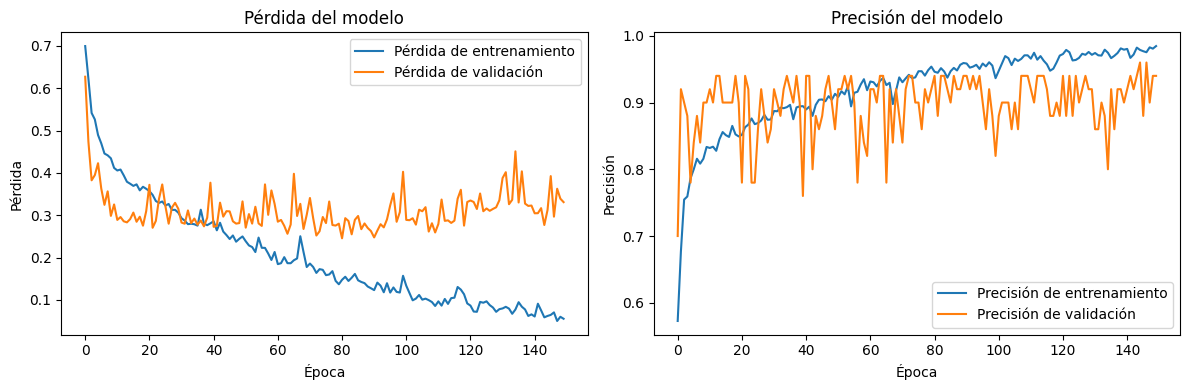

In [ ]:
act_l0 = "leaky_relu"
num_hidden_l0 = 85
dropout_l0 = 0.2000762398476158
act_l1 = "leaky_relu"
num_hidden_l1 = 65
dropout_l1 = 0.20827801097339319

learning_rate = 8.283112736649545e-05


checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    "weights-data/nn_model_checkpoint_epoch_{epoch:02d}.weights.h5",  # Save weights with epoch number
    save_weights_only=True,  # Saves only weights, not full model
    save_freq="epoch"  # Saves at every epoch
)

# The data is split between train and validation sets.
(x_train, y_train), (x_valid, y_valid) = (CE_x, CE_y), (CV_x, CV_y)

# We define our MLP.
model_cp = Sequential()
model_cp.add(Dense(num_hidden_l0, activation=act_l0))
model_cp.add(Dropout(rate=dropout_l0))
model_cp.add(Dense(num_hidden_l1, activation=act_l1))
model_cp.add(Dropout(rate=dropout_l1))
model_cp.add(Dense(1, activation="sigmoid"))

model_cp.compile(
        loss="binary_crossentropy",
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=["accuracy"],
    )

!mkdir weights-data/
history = model_cp.fit(
        x_train,
        y_train,
        batch_size=100,
        callbacks=[checkpoint_callback],
        epochs=150,
        validation_data=(x_valid, y_valid),
        verbose=1
    )

plt.figure(figsize=(12, 4))
 
# Gráfico de pérdida
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.title('Pérdida del modelo')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
 
# Gráfico de precisión
plt.subplot(1, 2, 2)
if 'accuracy' in history.history:
    plt.plot(history.history['accuracy'], label='Precisión de entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Precisión de validación')
    plt.title('Precisión del modelo')
    plt.xlabel('Época')
    plt.ylabel('Precisión')
    plt.legend()
elif 'acc' in history.history:
    plt.plot(history.history['acc'], label='Precisión de entrenamiento')
    plt.plot(history.history['val_acc'], label='Precisión de validación')
    plt.title('Precisión del modelo')
    plt.xlabel('Época')
    plt.ylabel('Precisión')
    plt.legend()
 
plt.tight_layout()
plt.show()

Epoch 145 Training Accuracy: 0.9788
Epoch 145 Validation Accuracy: 0.9600


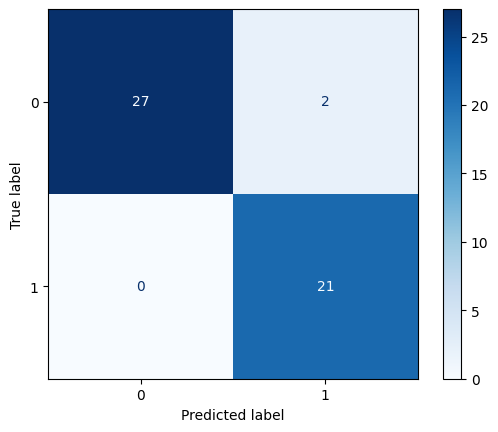

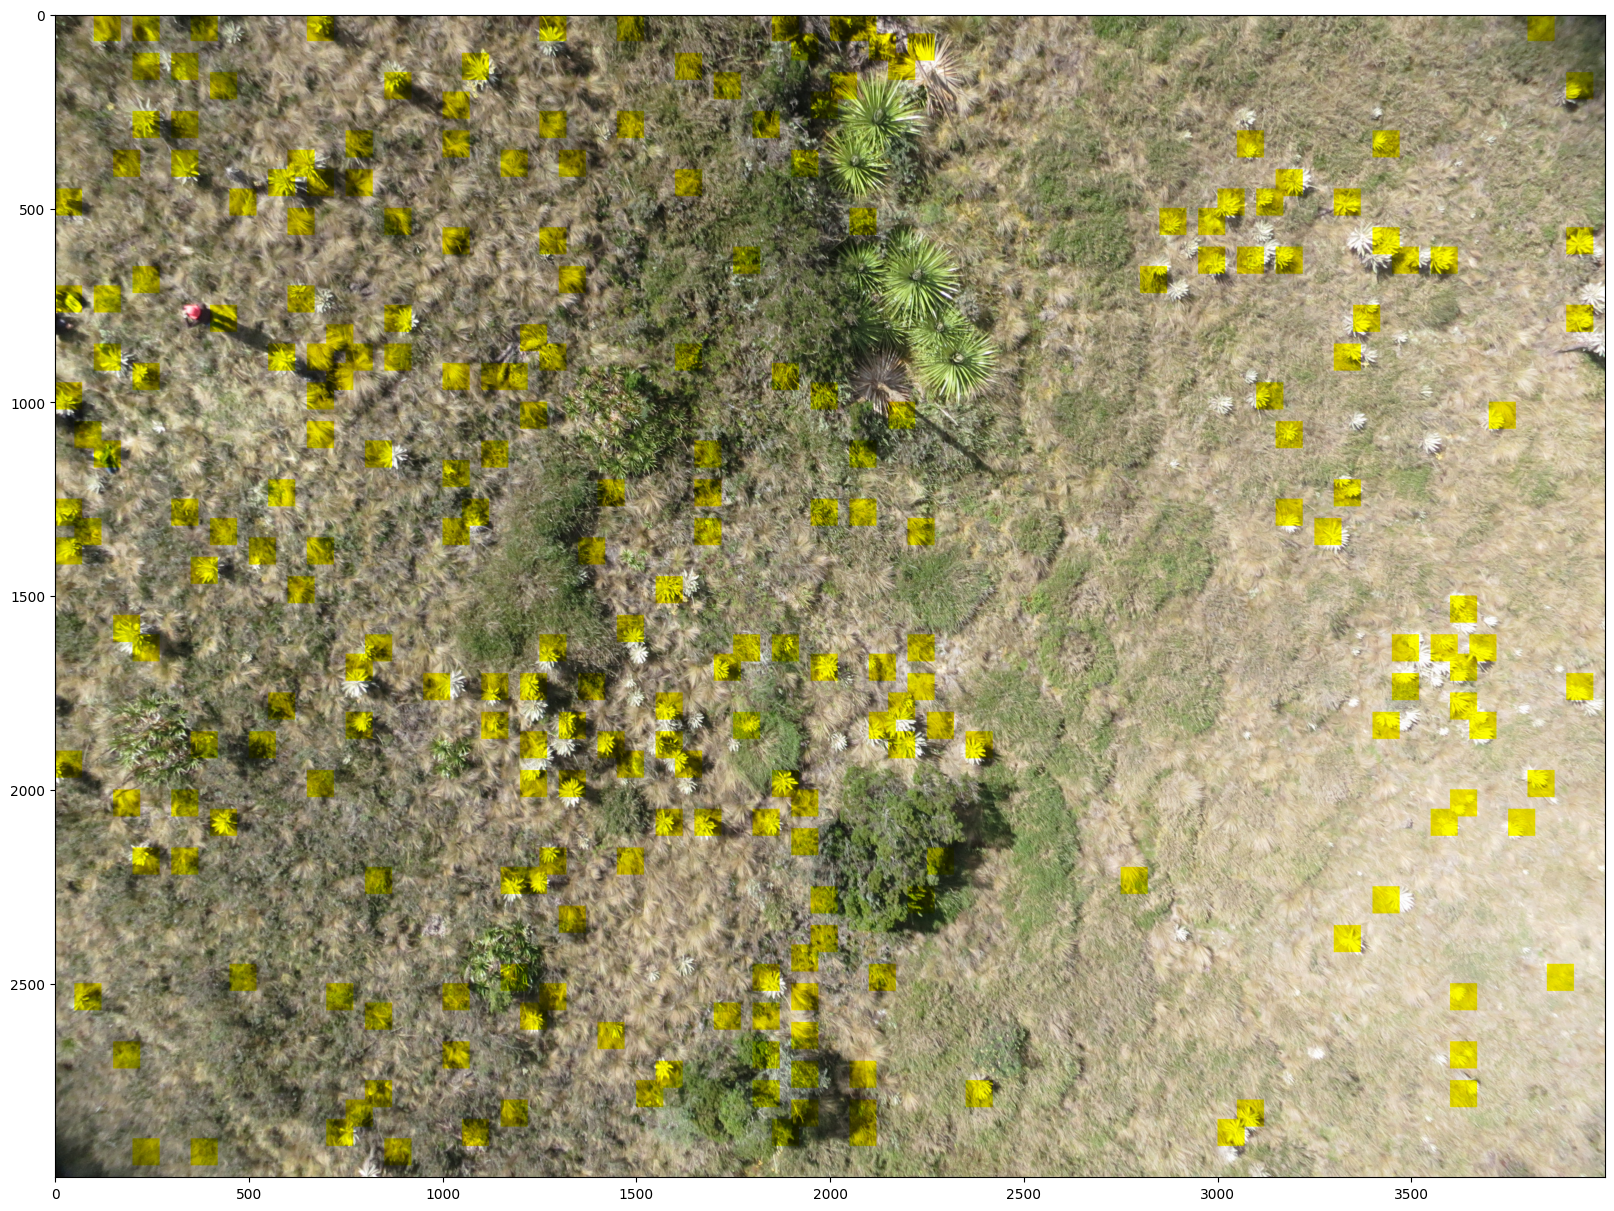

In [ ]:
best_epoch = 145

model_cp.load_weights(f"weights-data/nn_model_checkpoint_epoch_{best_epoch}.weights.h5")

train_accuracy_best_epoch = history.history["accuracy"][best_epoch - 1]
val_accuracy_best_epoch = history.history["val_accuracy"][best_epoch - 1]

print(f"Epoch {best_epoch} Training Accuracy: {train_accuracy_best_epoch:.4f}")
print(f"Epoch {best_epoch} Validation Accuracy: {val_accuracy_best_epoch:.4f}")


y_pred_probs = model_cp.predict(x_valid, verbose=0)  
y_pred = (y_pred_probs > 0.5).astype(int)

y_pred_probs_t = model_cp.predict(x_train, verbose=0)  
y_pred_t = (y_pred_probs_t > 0.5).astype(int)

cm = confusion_matrix(y_valid, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.show() 


img = load_img('IMG_3451.JPG')
img = np.array(img)  
# Lo pasamos por nuestra imagen de prueba
x = np.array(img)
x2 = x

ni = x.shape[0]-50
mi = x.shape[1]-50

f1=0
f2=70
for i in range(1,ni,50):
    c1=0
    c2=70
    for j in range(1,mi,50):
        subi=x[f1:f2,c1:c2,]
        subi2=np.ndarray.flatten(subi).T/255.
        ns=subi2.shape[0]
        vec=subi2
        vec.shape=(ns,1)
        pred_P=(model_cp.predict(vec.T, verbose=0) > 0.5).astype(int)
        if(pred_P==1):
            x2[f1:f2,c1:c2,2]=0
        c1=c1+50
        c2=c2+50
    f1=f1+50
    f2=f2+50

plt.figure(figsize = (20,20))
plt.imshow(x2)



2. Implementa una red neuronal multi-capa


3. Implementa una red neuronal convolucional





4. Implementa una red neuronal convolucional con tranferencia VGG-16



5. Implementa una red neuronal convolucional con tranferencia VGG-16 y ajuste de hiperparámetros (bono por uso de Optuna).






6. Responda: **¿Qué puede observar sobre el desempeño de los diferentes modelos? Argumente cuál es el mejor modelo para poner en producción.**

7. Investigue otra red pre-entrenada dsitinta a la VGG-16 e implemente el aprendizaje por transferencia para la deteccion de frailejones. Argumente por qué su justifica el aprendizaje por transferencia con base en el modelo pre-entrenado de su elección (cómo se relacionan la tarea base y la segunda tarea objetivo).

### Cálculo de densidad poblacional por grupos de Frilejones

Iniciaremos con el cálculo total de frilejones en la imagen y con ello (de acuerdo con la ayuda) tendrémos la densidad de frilejones. Para ello únicamente correremos el loop nuevamente y cambiaremos un poco sus parametros para contar el número exacto de frilejones en la imagen.

NOTA: aprovecharemos también para sacar la ubicaciónd de cada frilejon simulando "latitud y longitud". Como se muestra en la siguiente imagen:


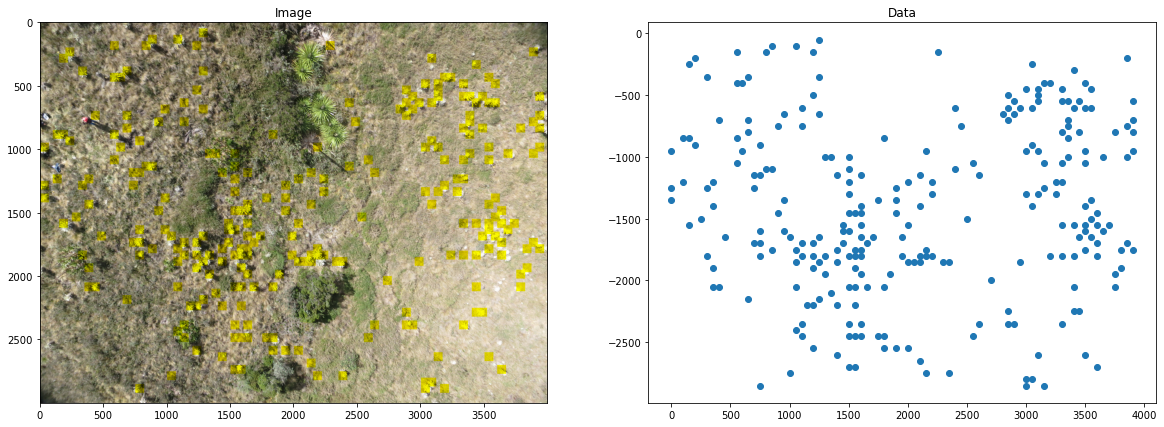


Una vez calculada la cantidad total de frilejones en la imagen, debe hacer el cálculo de la densidad poblacional. Se recomienda el uso de un GMM o puede aplicar algún análisis, heurística que identifique los grupos de frilejosnes en la imagen y la densidad en cada grupo.